In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('/content/mimic_iv_merged_data_cleaned (2).csv')

In [ ]:
# Comorbidity columns
comorbidity_cols = [
    'myocardial_infarction',
    'congestive_heart_failure',
    'peripheral_vascular_disease',
    'cerebrovascular_disease',
    'dementia',
    'chronic_pulmonary_disease',
    'rheumatic_disease',
    'peptic_ulcer_disease',
    'diabetes',
    'paraplegia',
    'renal_disease',
    'malignant_cancer',
    'severe_liver_disease',
    'aids'
]

# All average-value columns, include both labs + vitals
avg_cols = [col for col in df.columns if col.endswith('_avg')]

# Create DataFrame
df_avg = df[comorbidity_cols + avg_cols + ['mortality_flag']].copy()

# Normality Plots **(qq-normal plots + histograms)** for Labs + Vitals, except for comorbid diseases


In [ ]:
# Identify columns to plot: all numeric columns in df_avg, excluding comorbidity_cols and 'mortality_flag'
# Make sure to only include columns that are actually in df_avg
columns_to_plot = [col for col in df_avg.select_dtypes(include=np.number).columns
                   if col not in comorbidity_cols and col != 'mortality_flag']

# Filter out columns that are entirely NaN, as box plots won't be useful for them
columns_to_plot = [col for col in columns_to_plot if not df_avg[col].isnull().all()]

Generating Q-Q plots and Histograms...


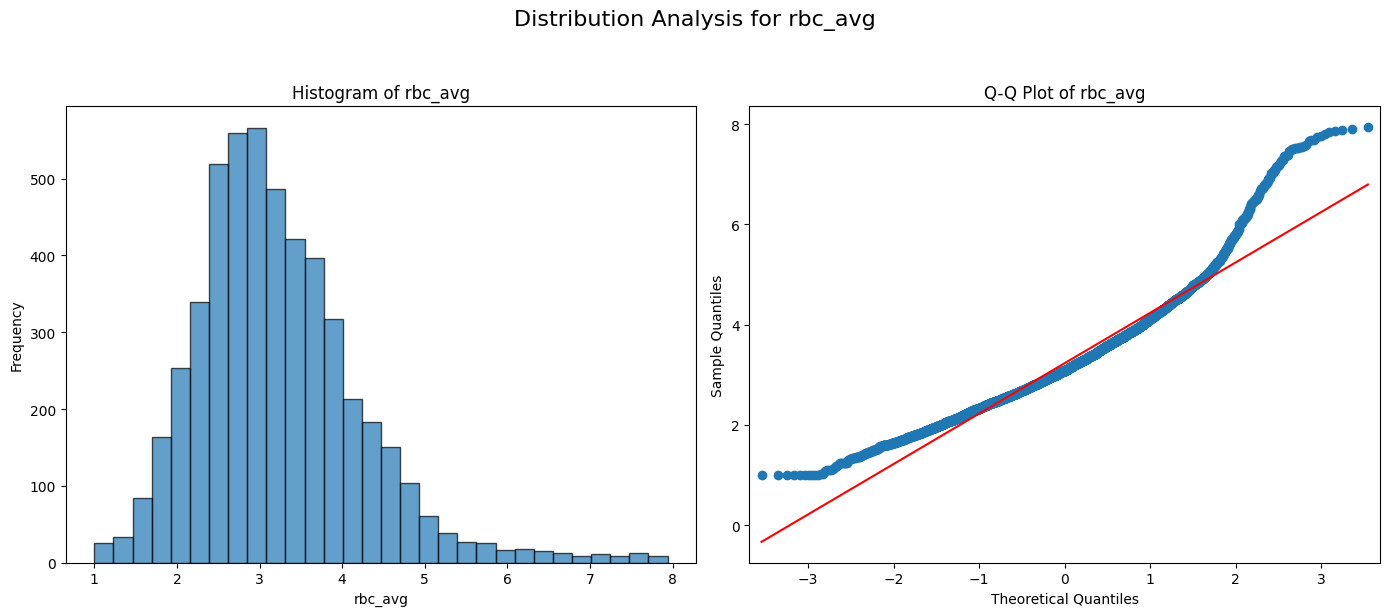

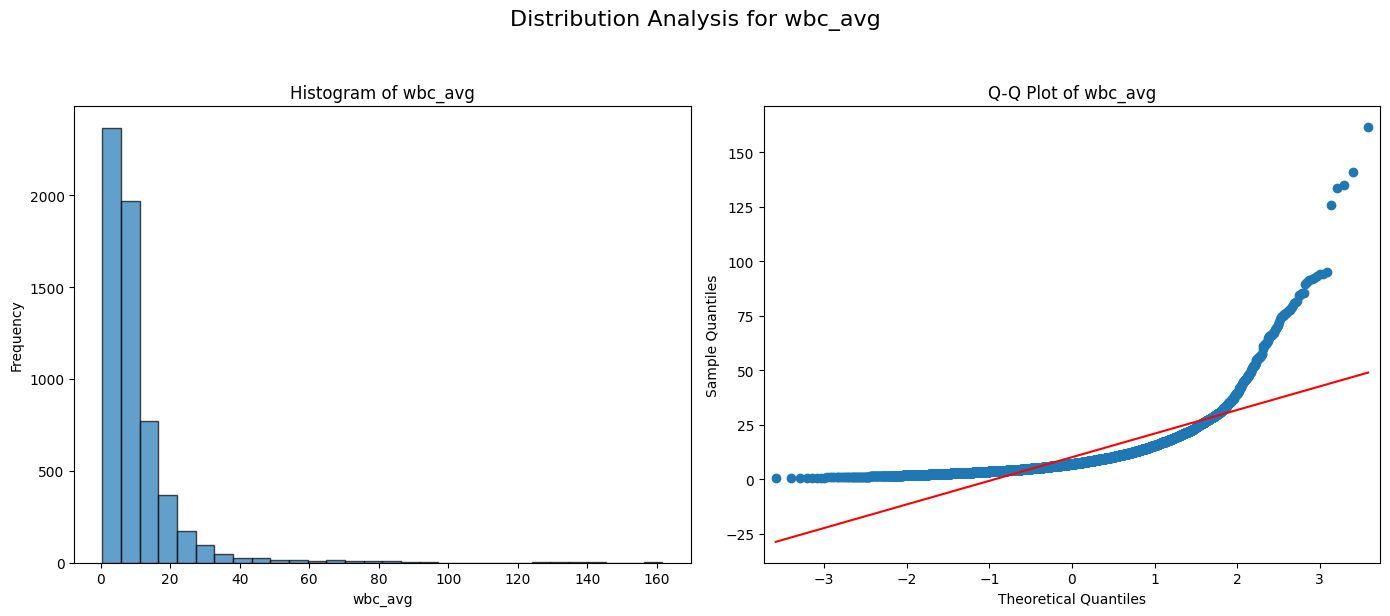

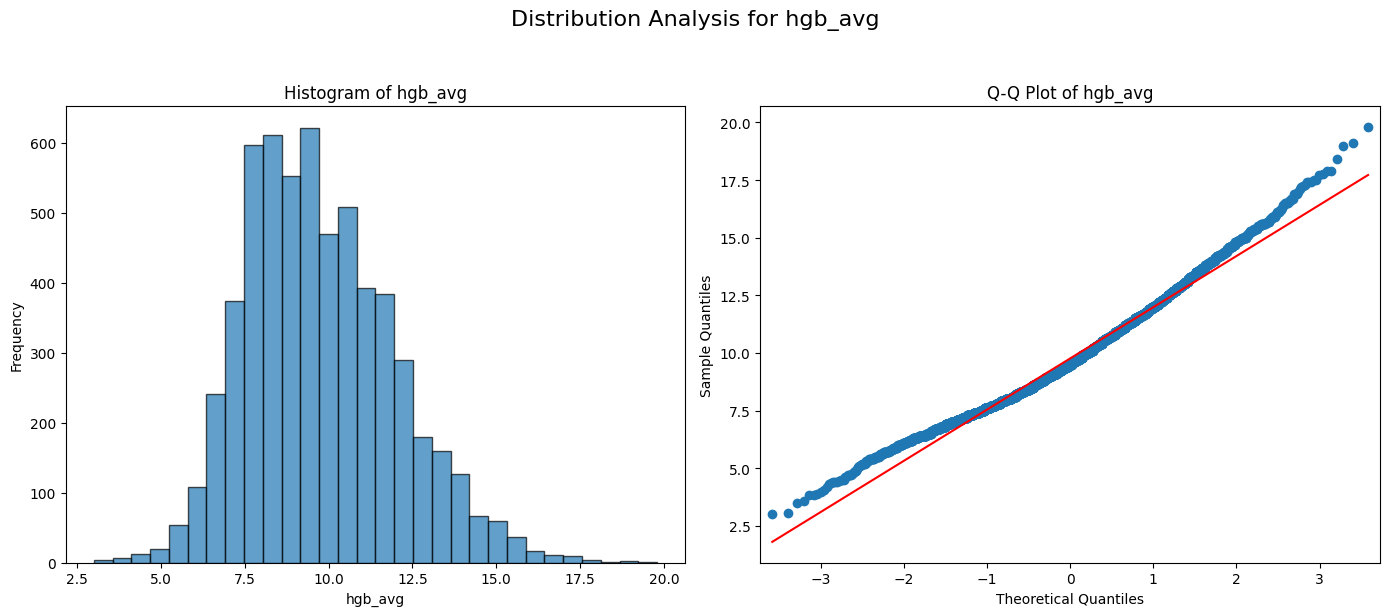

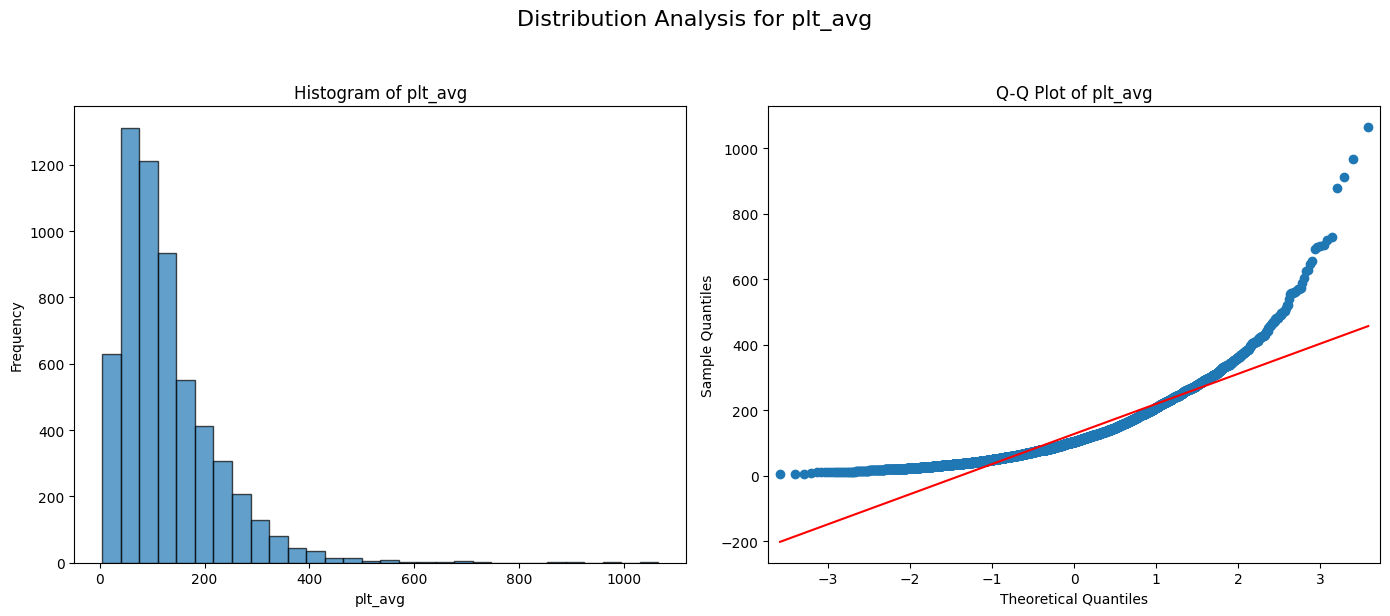

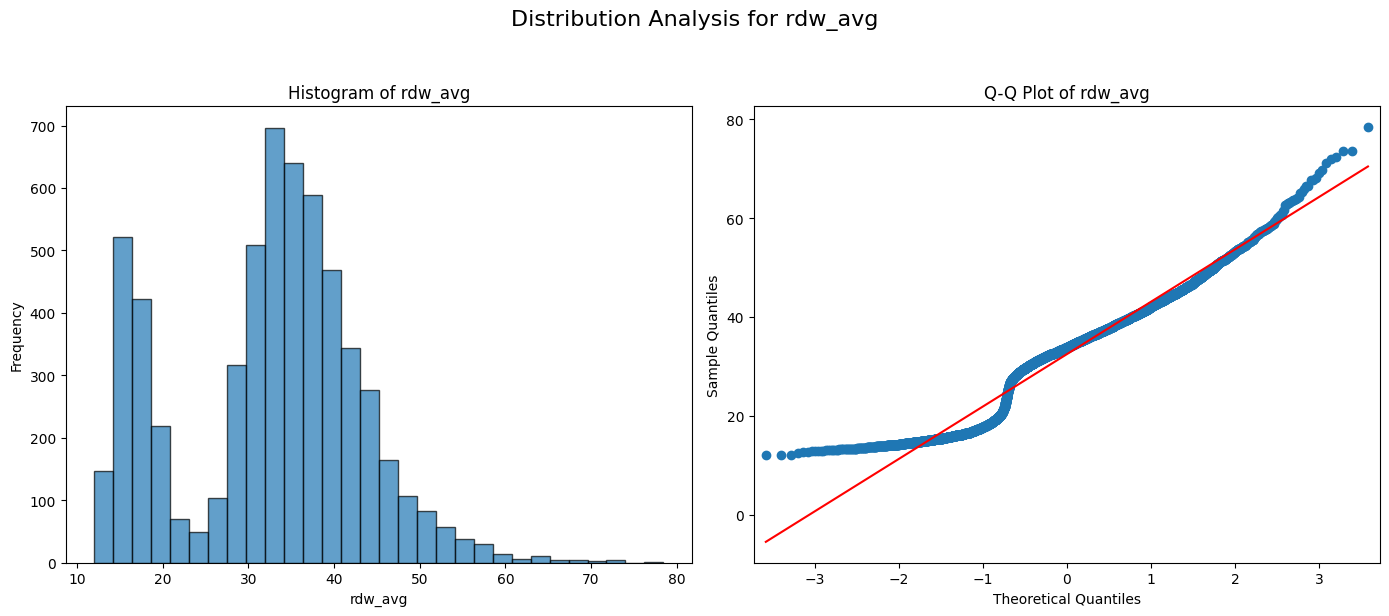

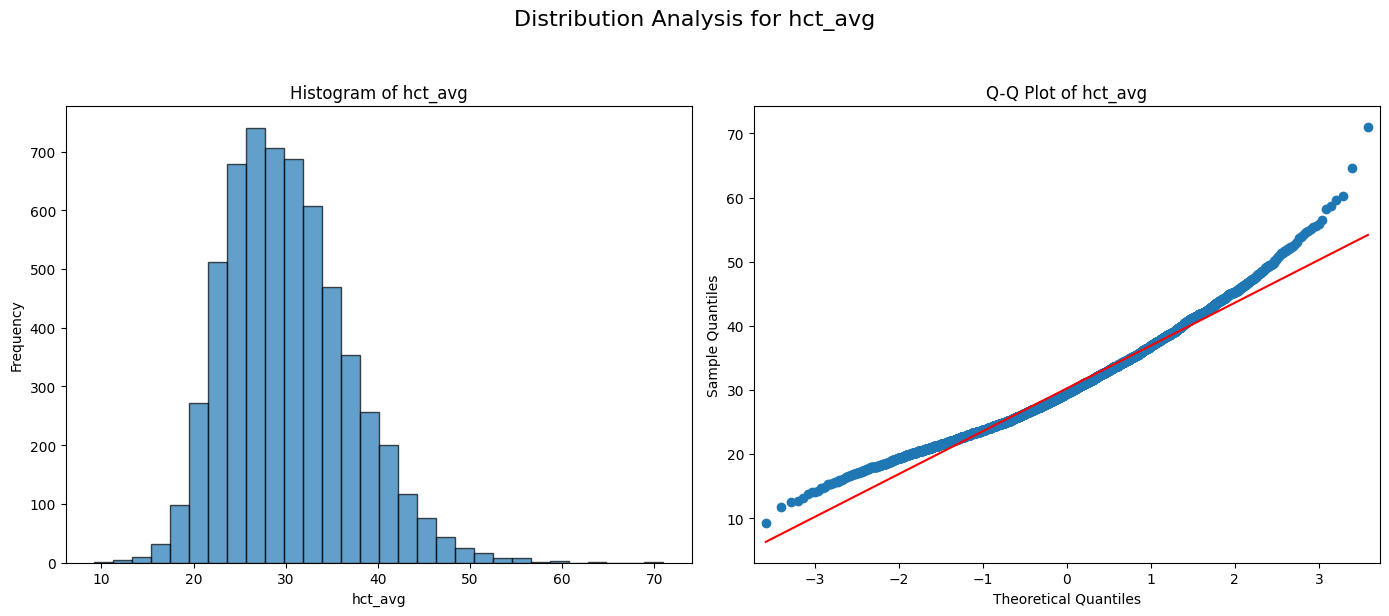

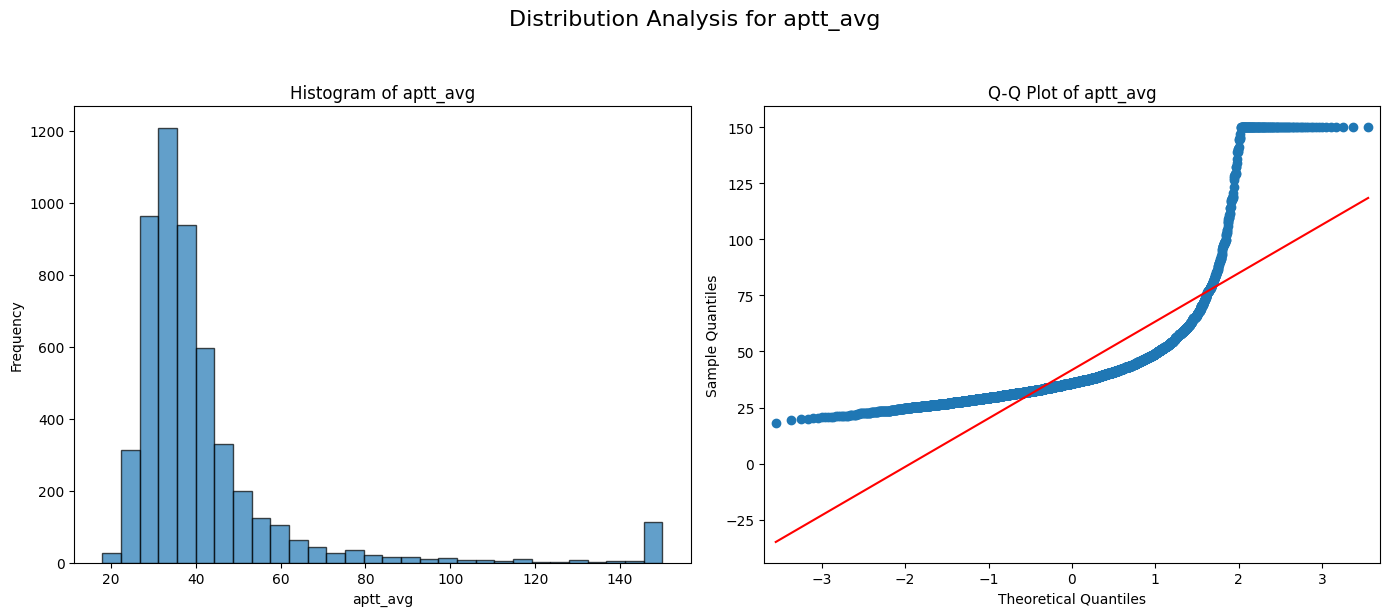

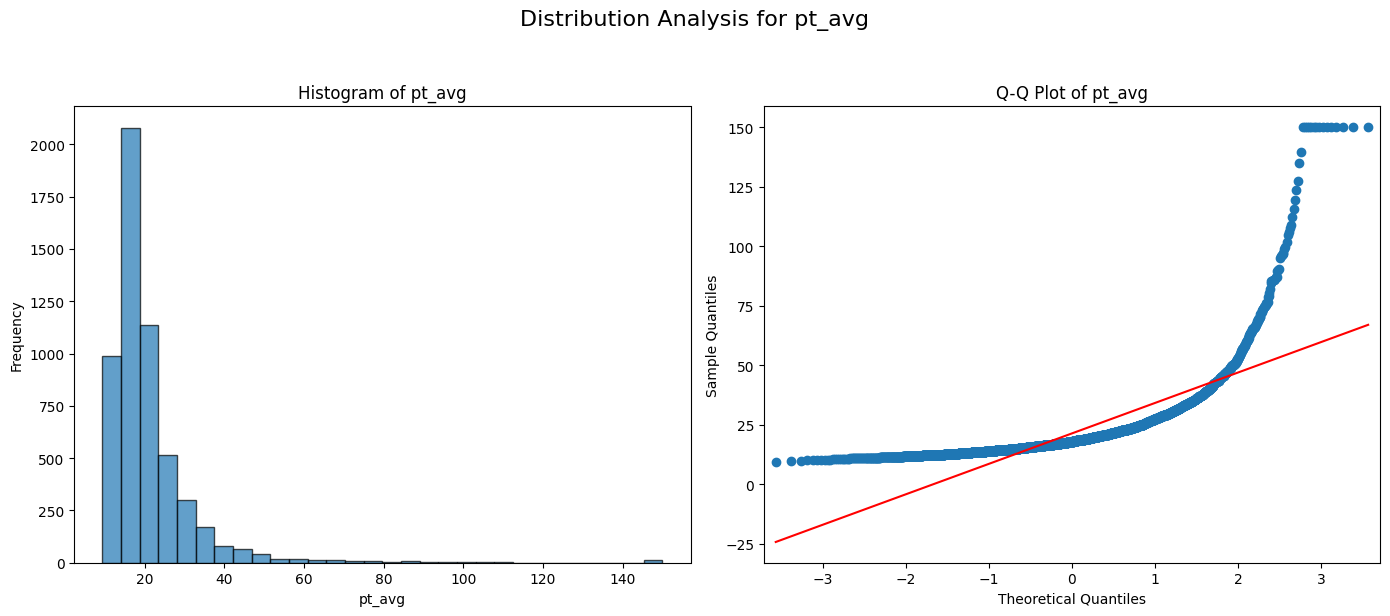

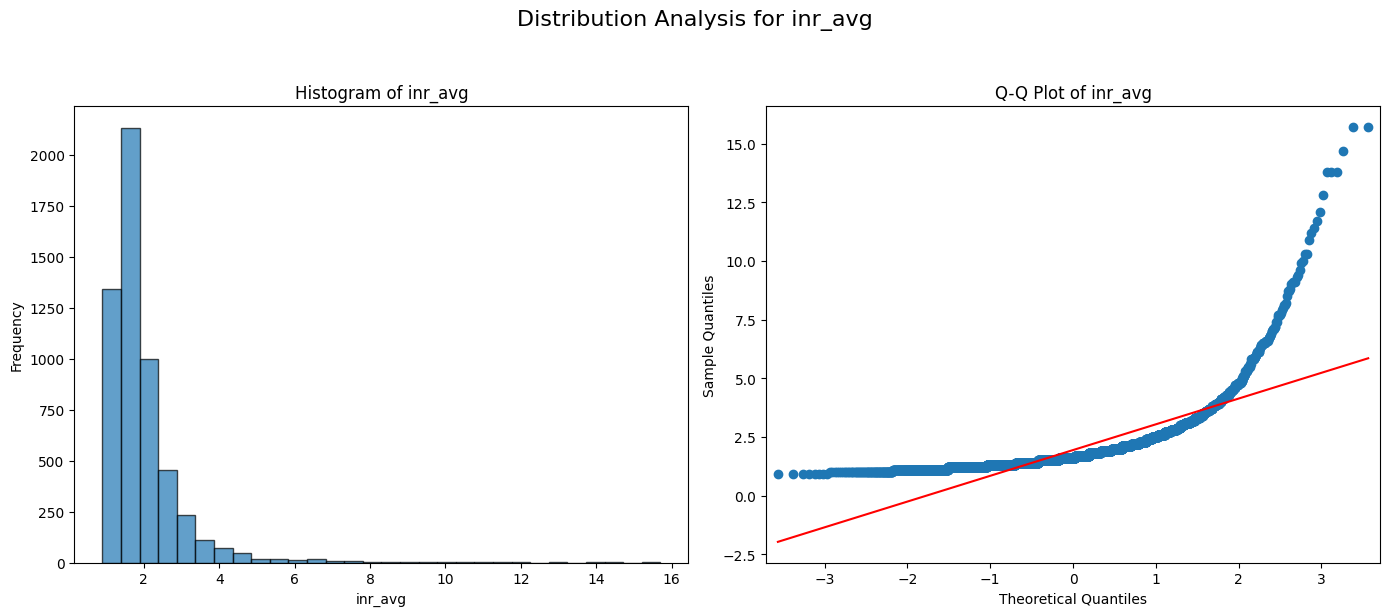

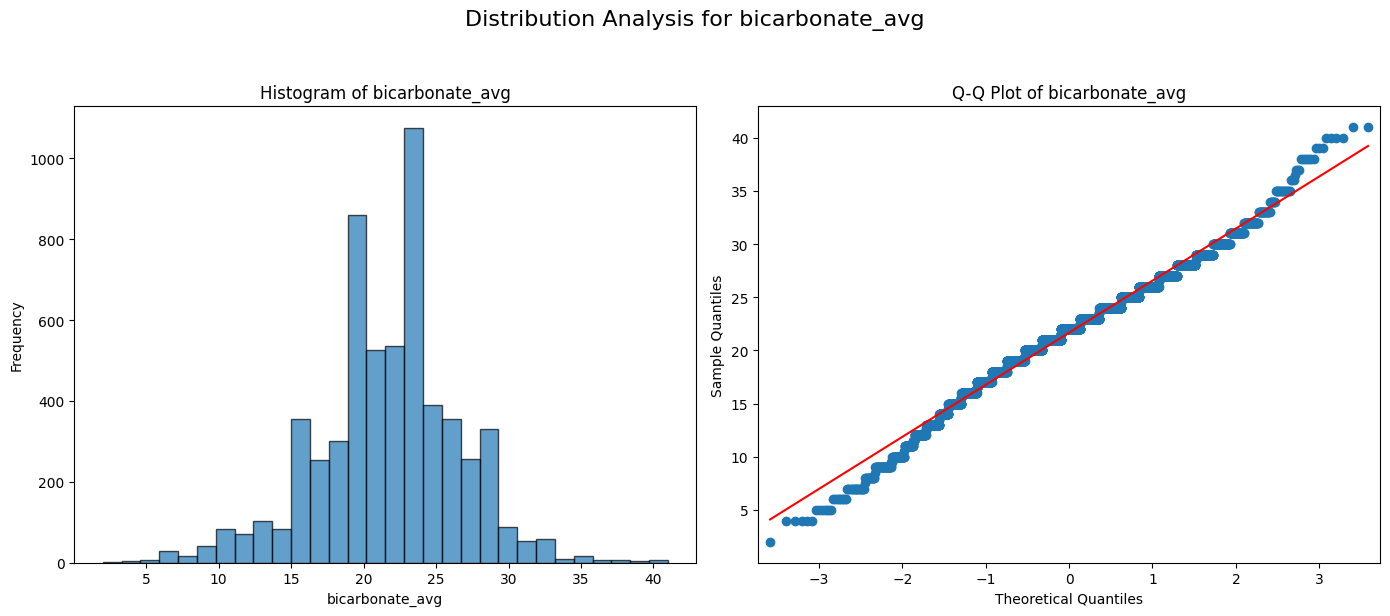

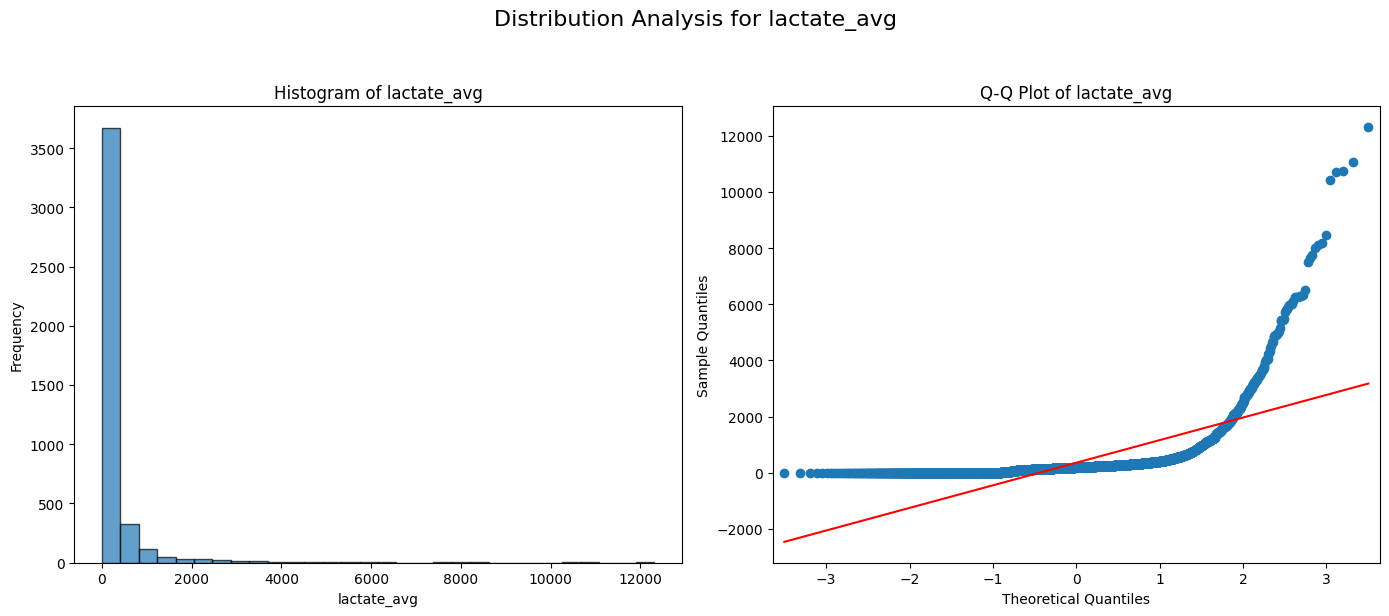

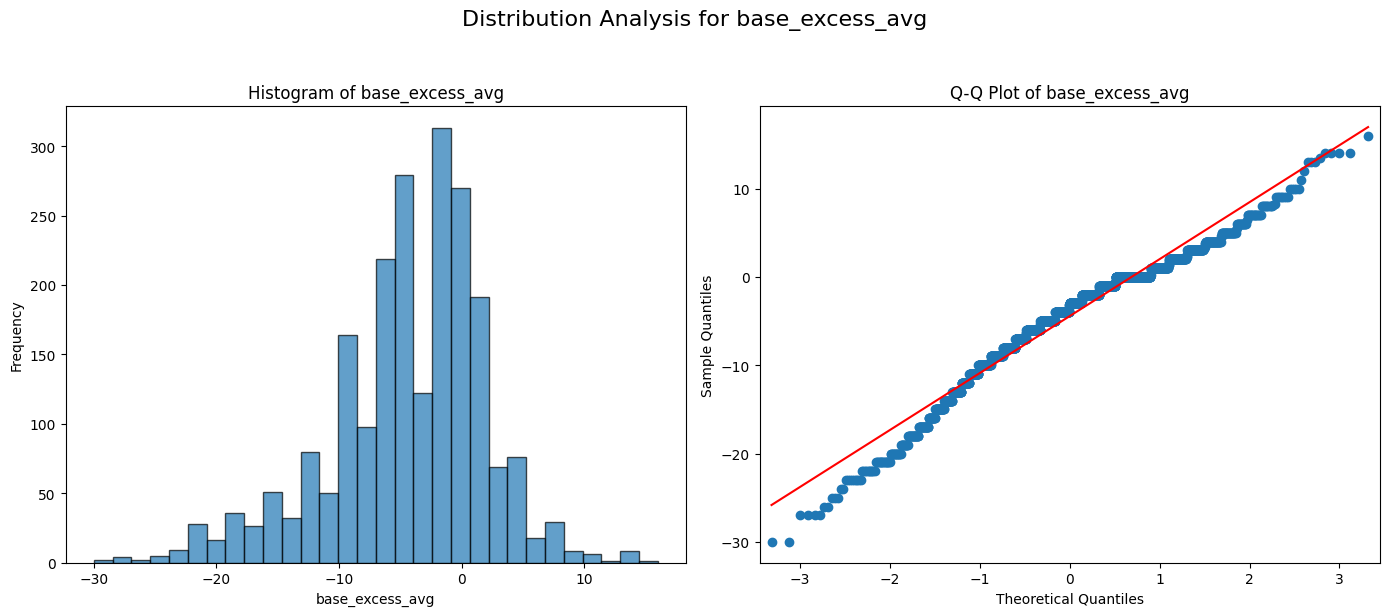

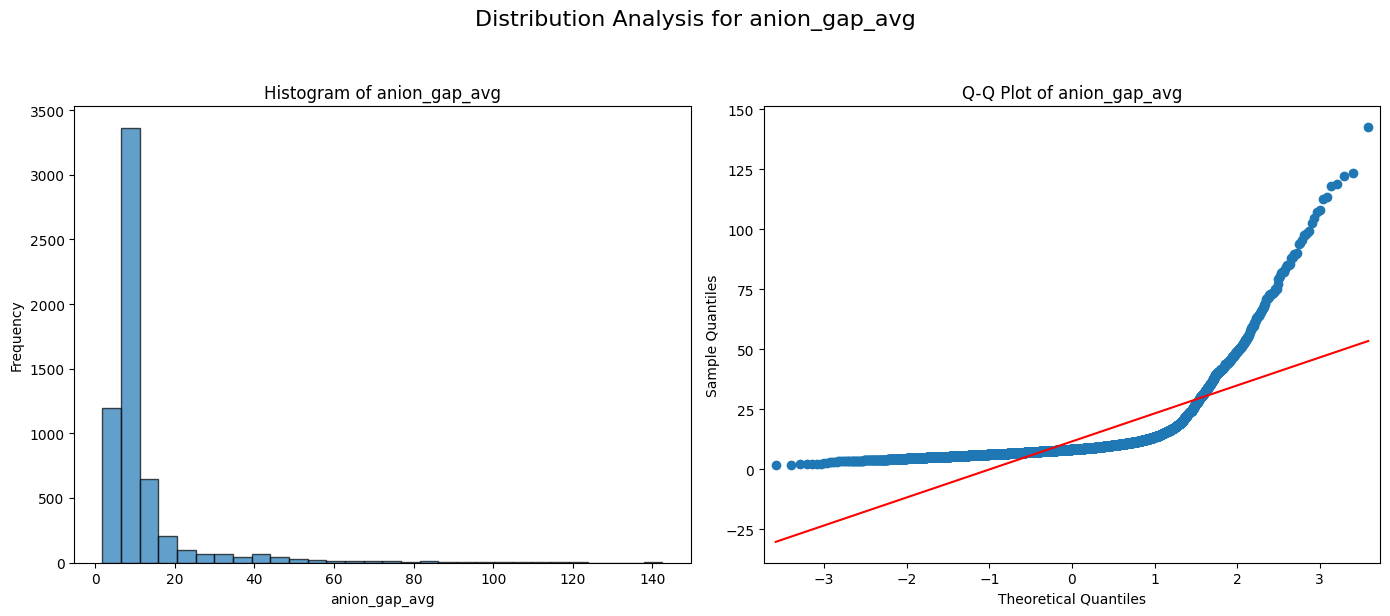

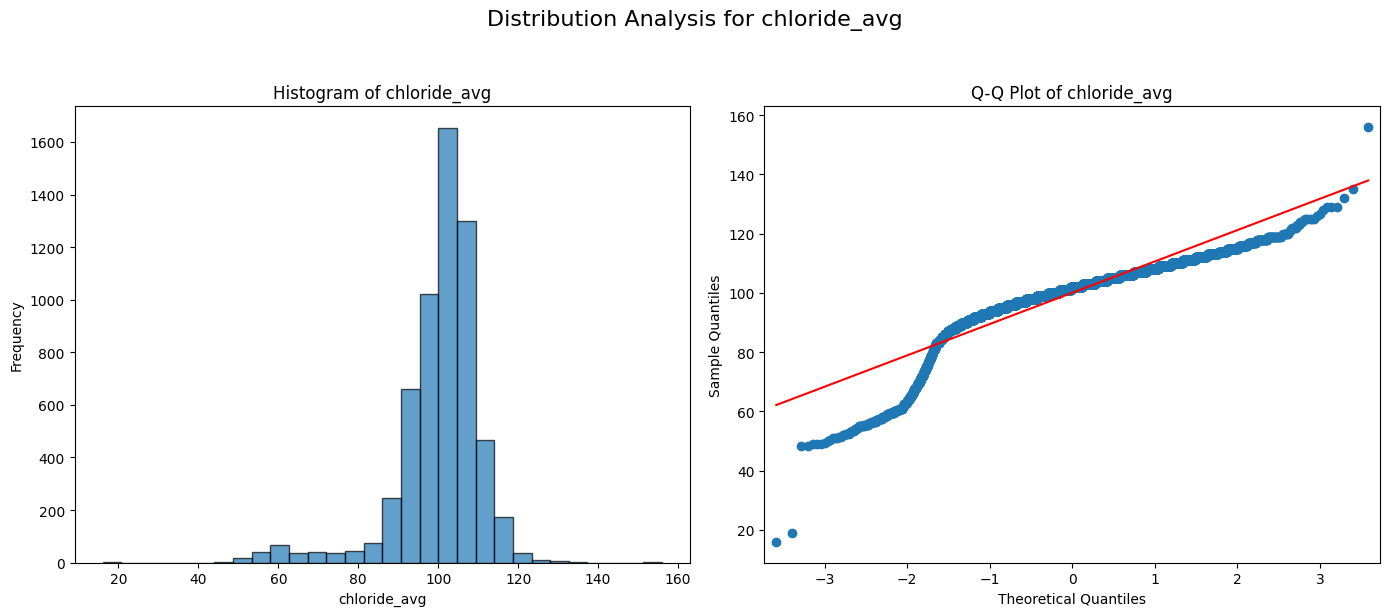

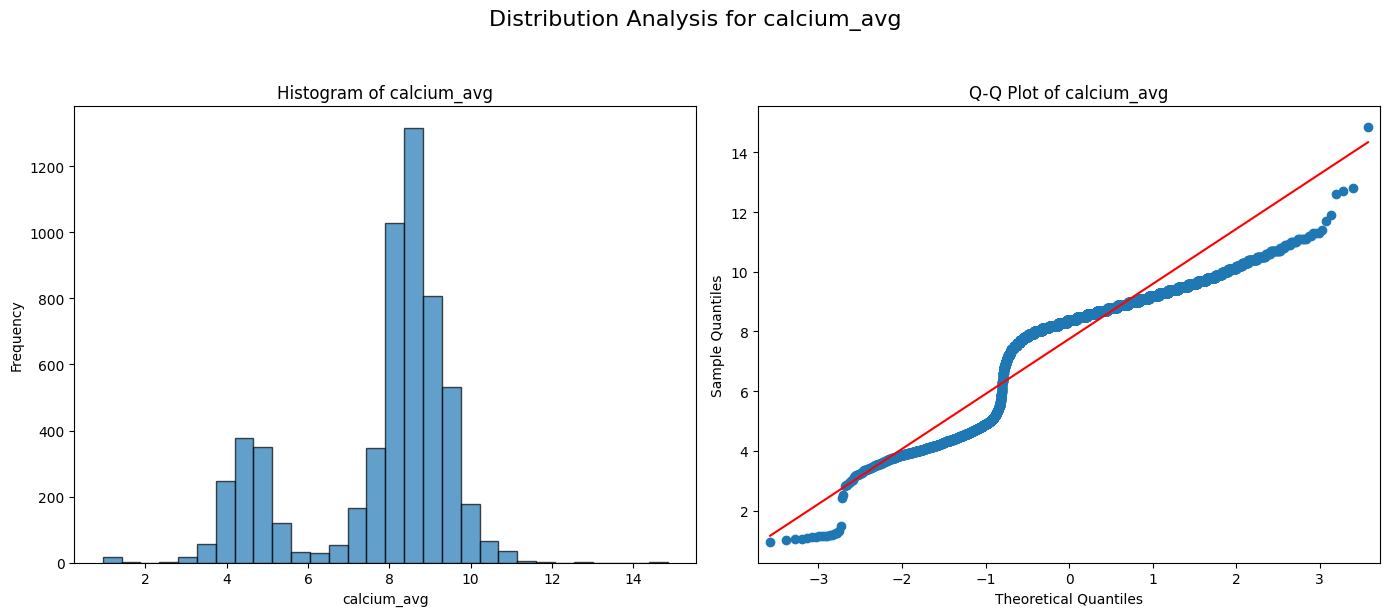

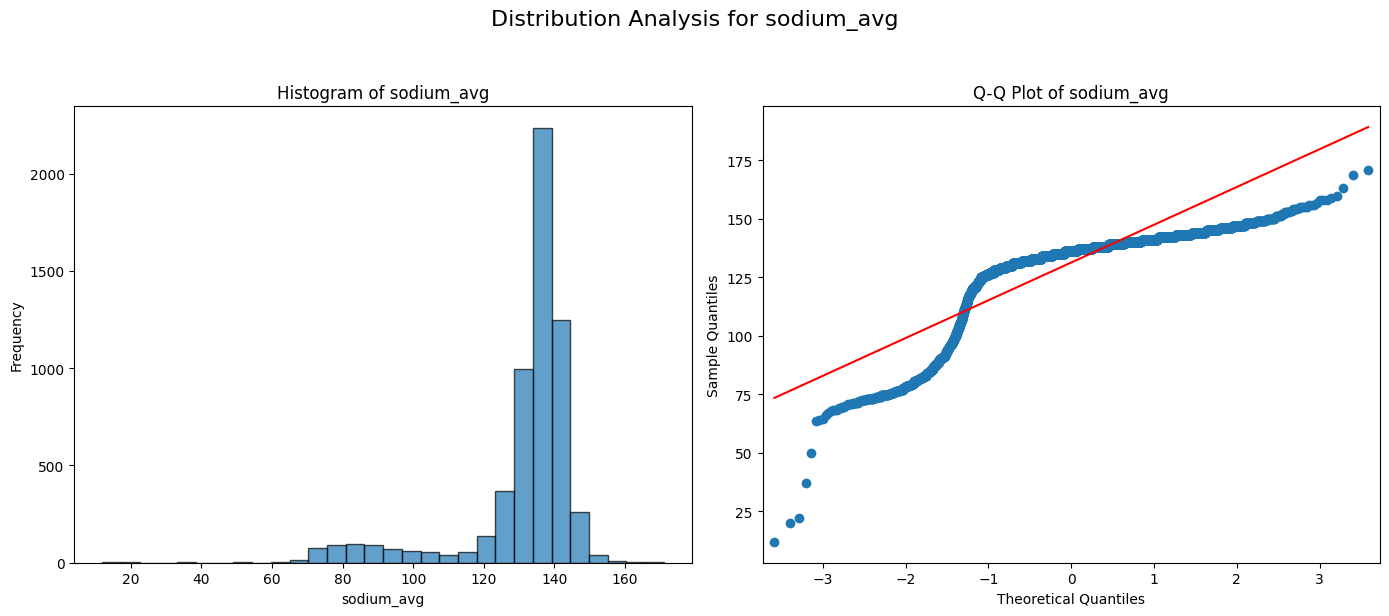

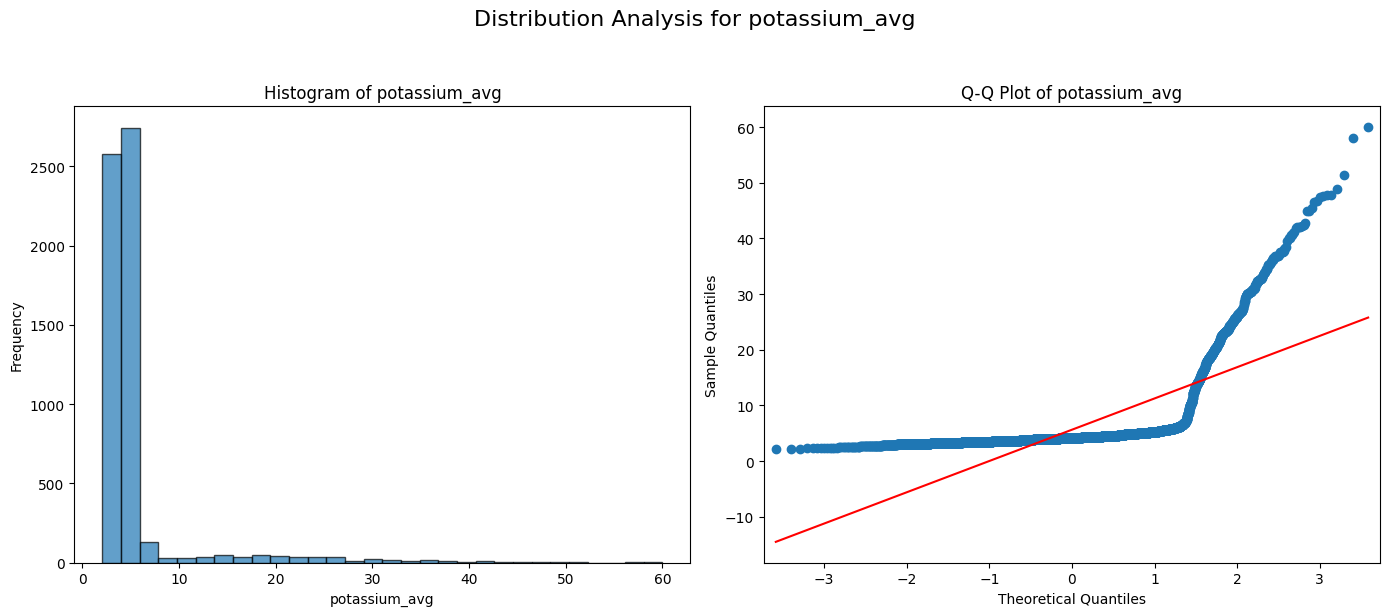

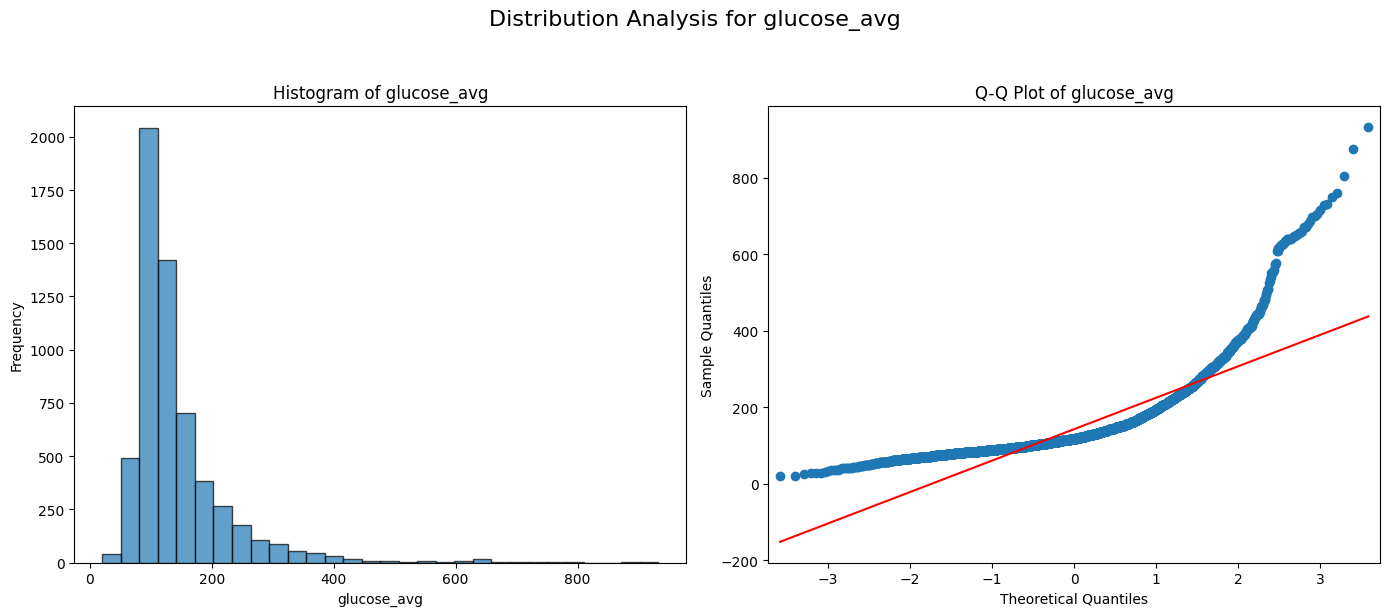

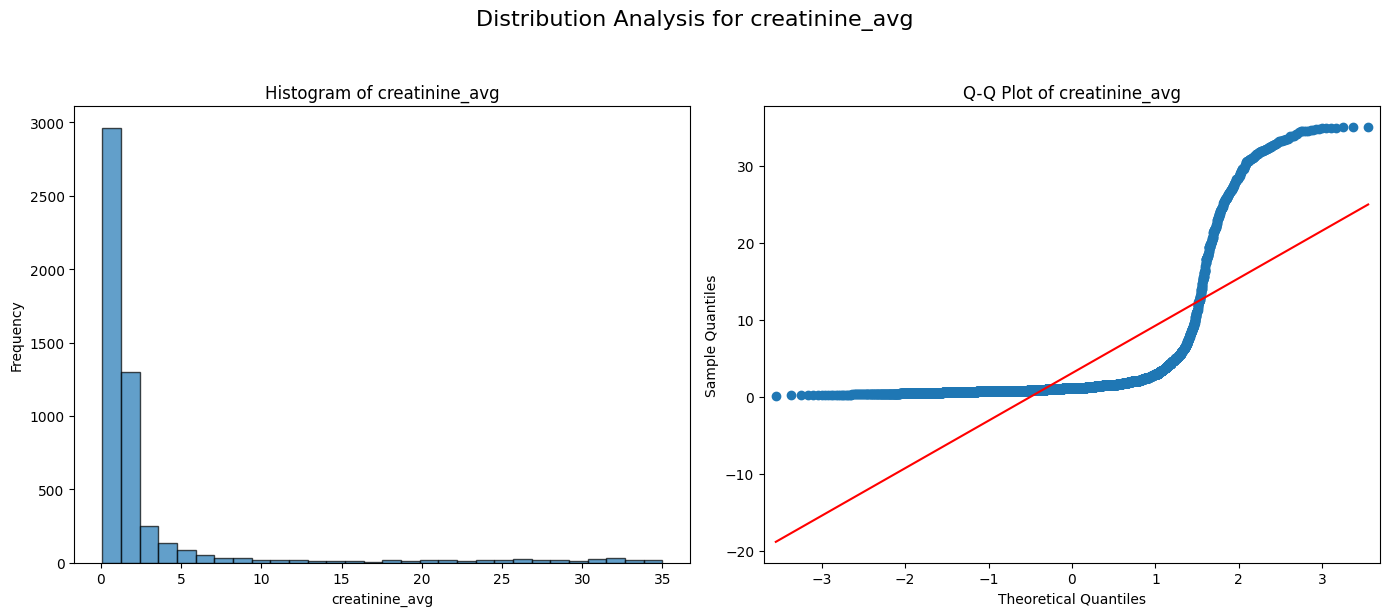

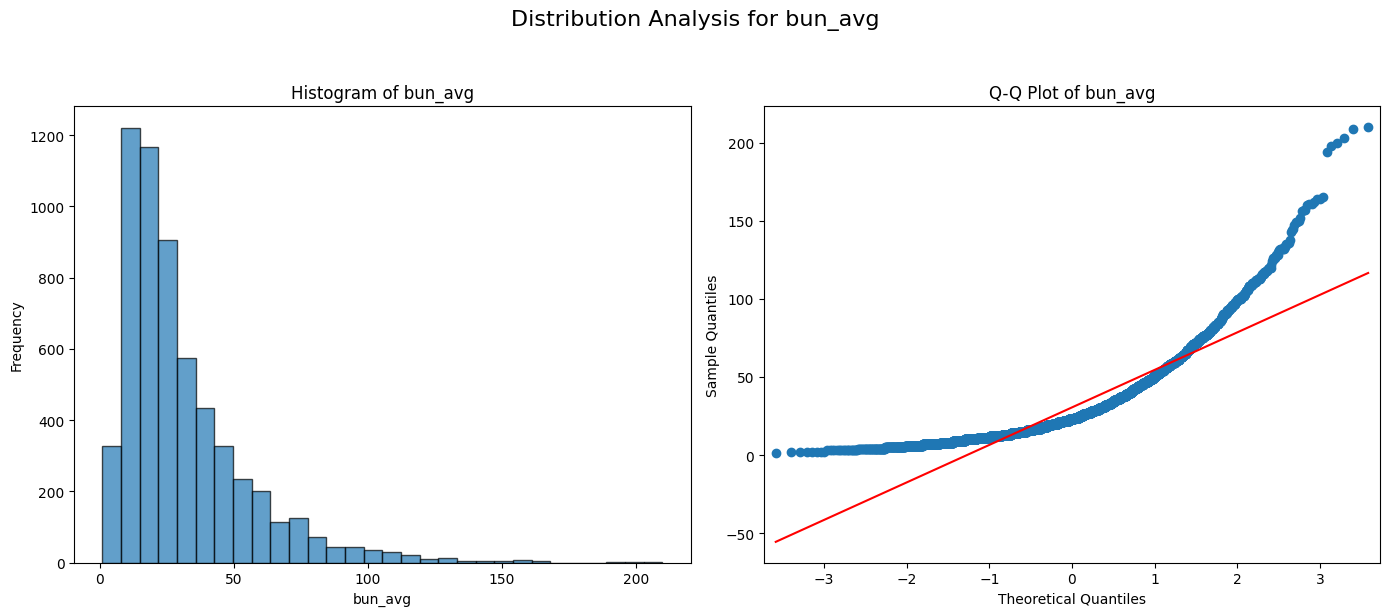

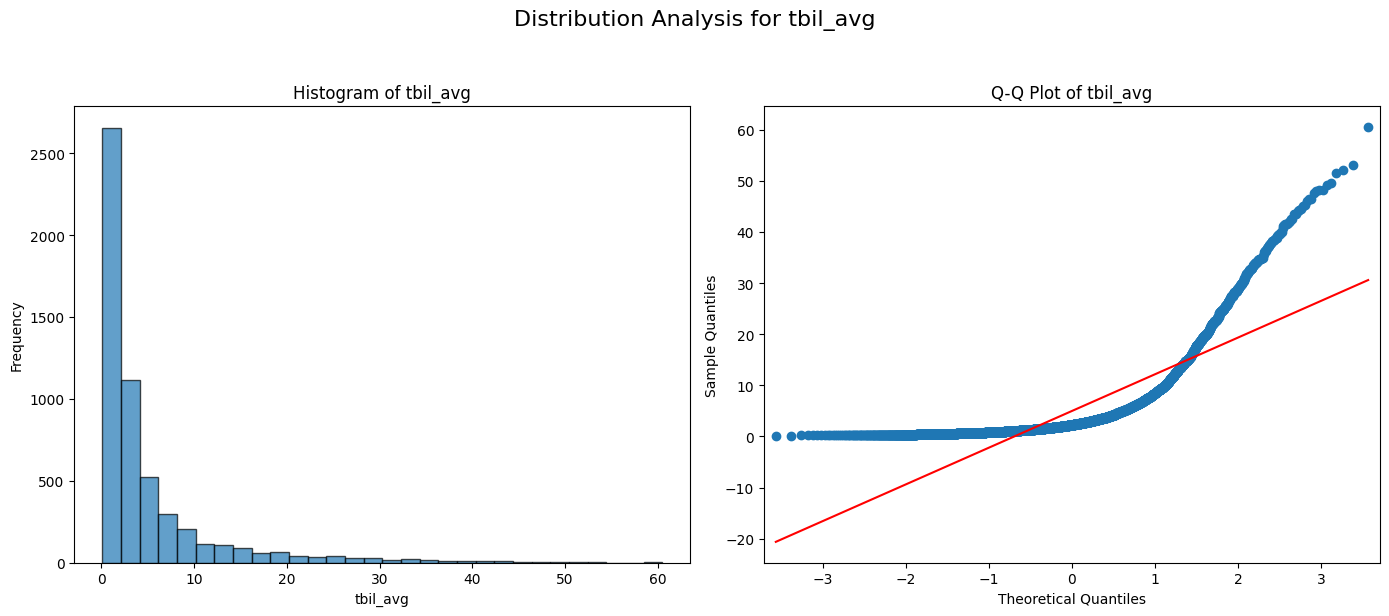

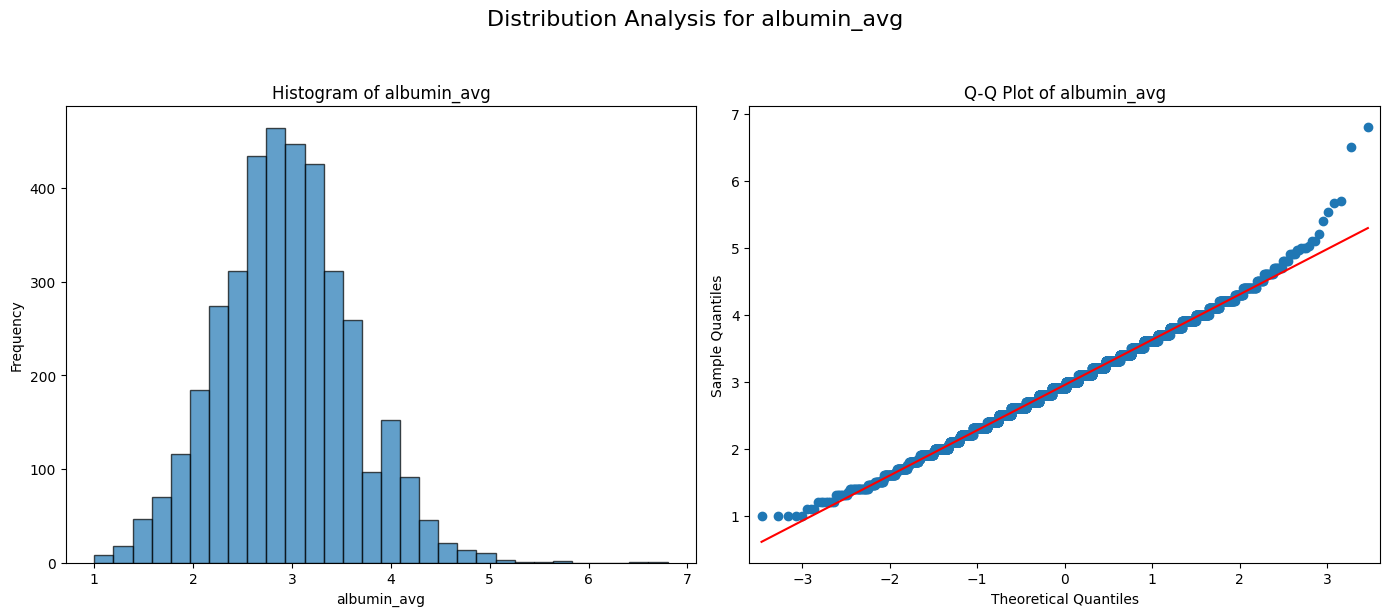

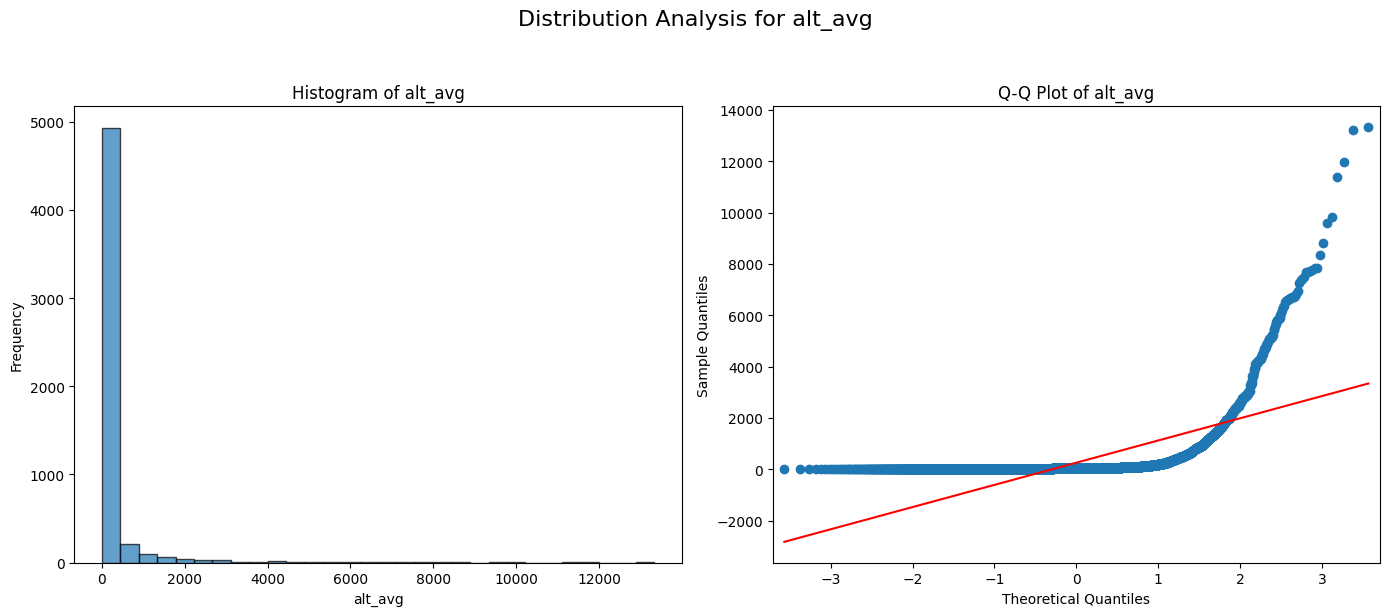

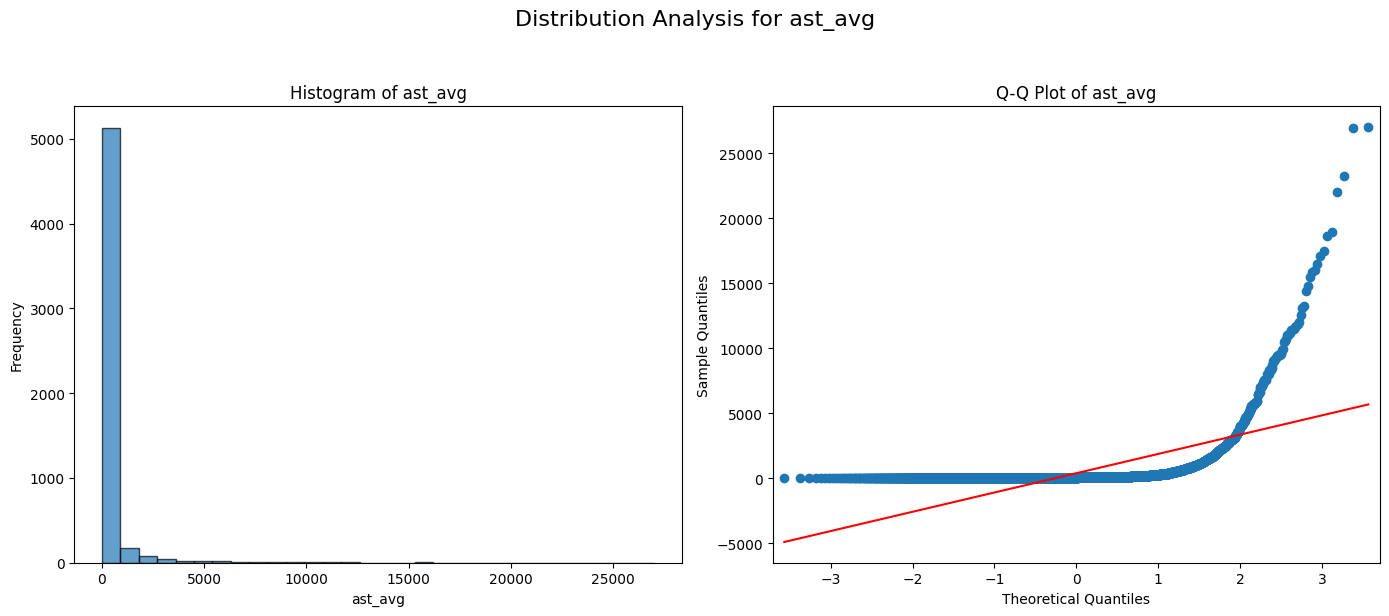

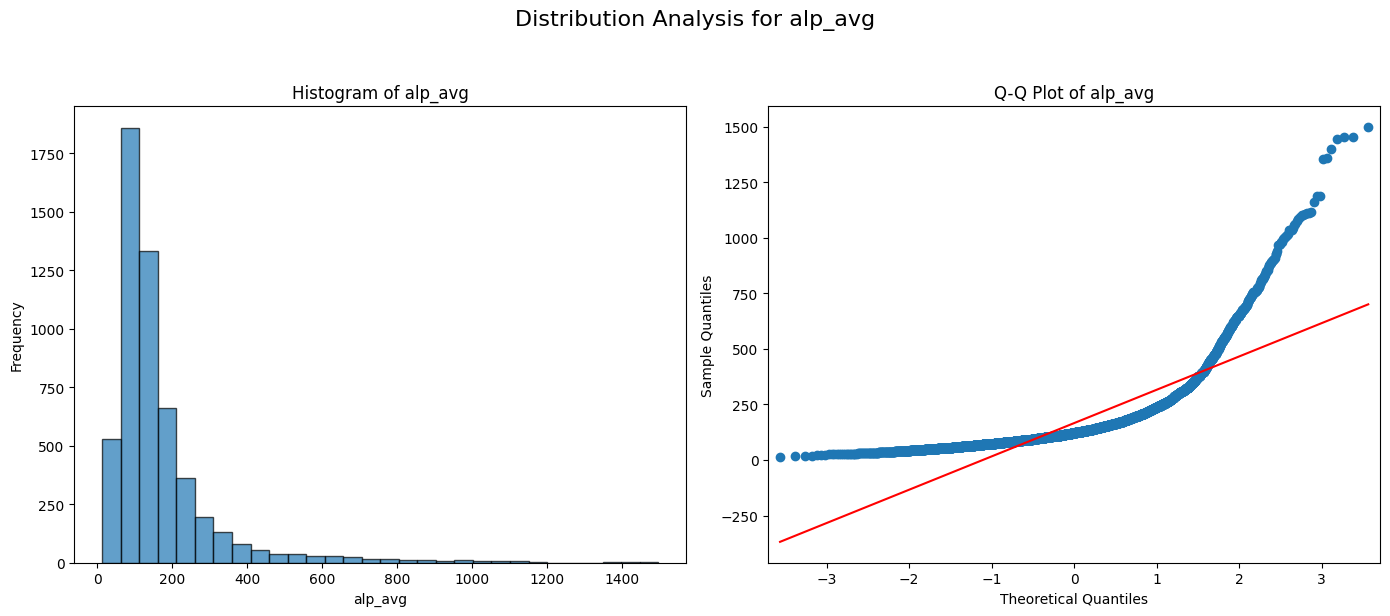

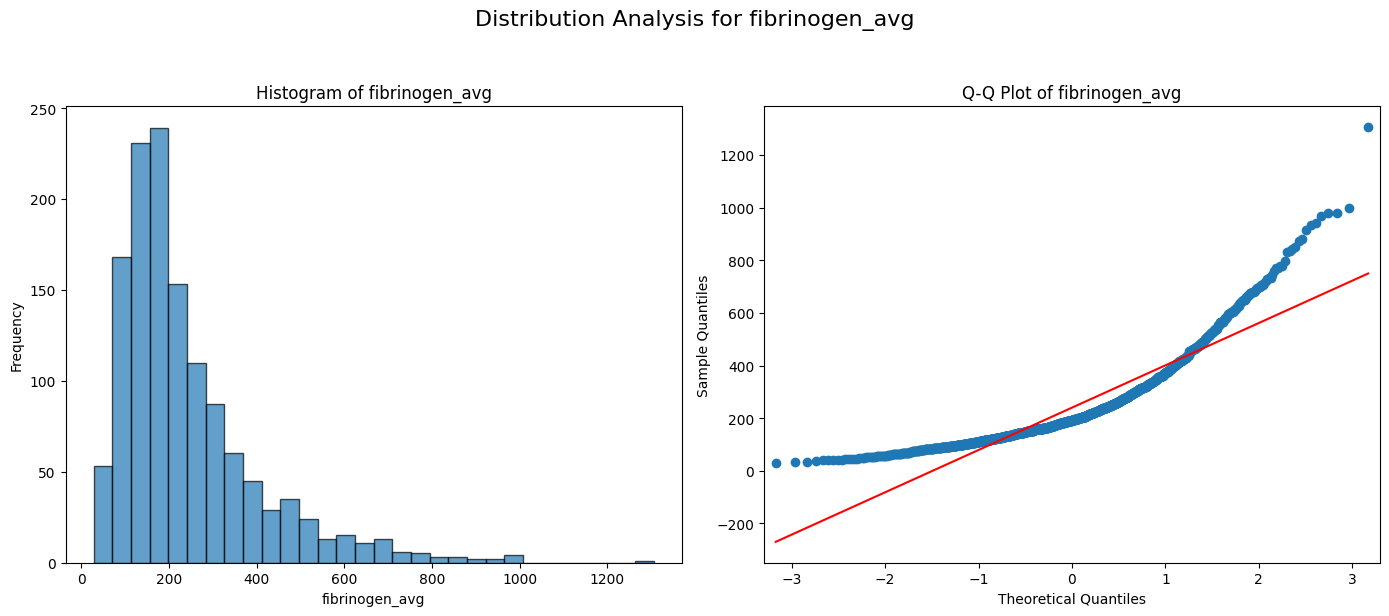

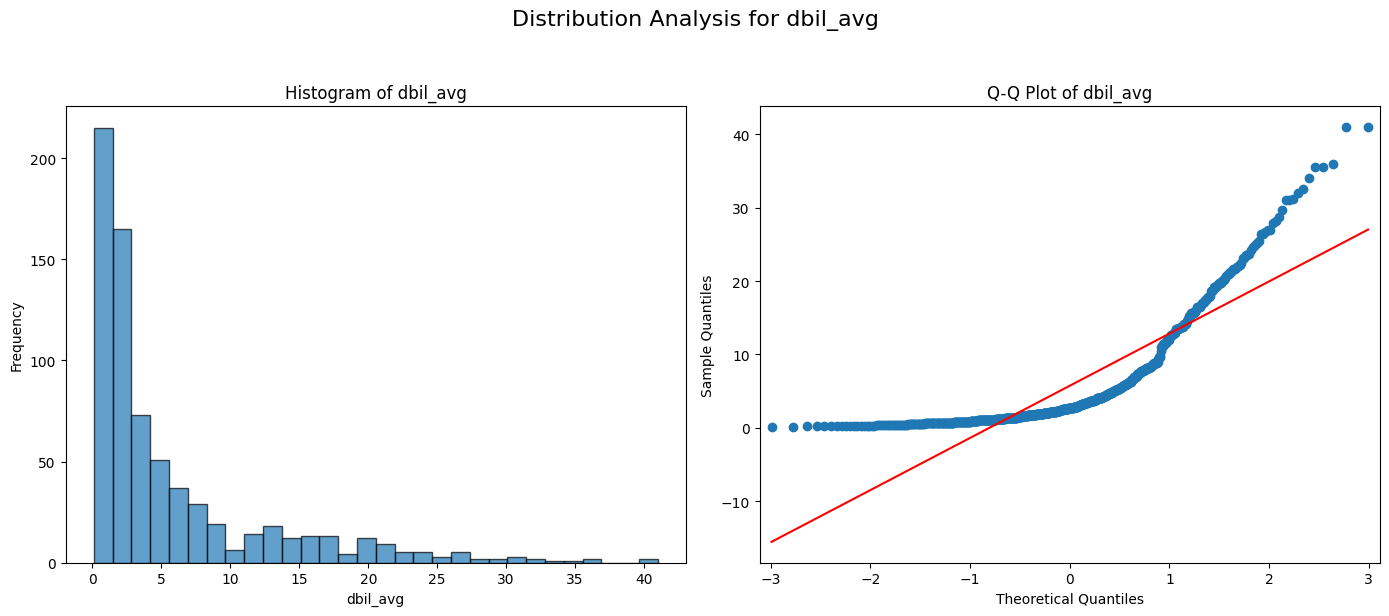

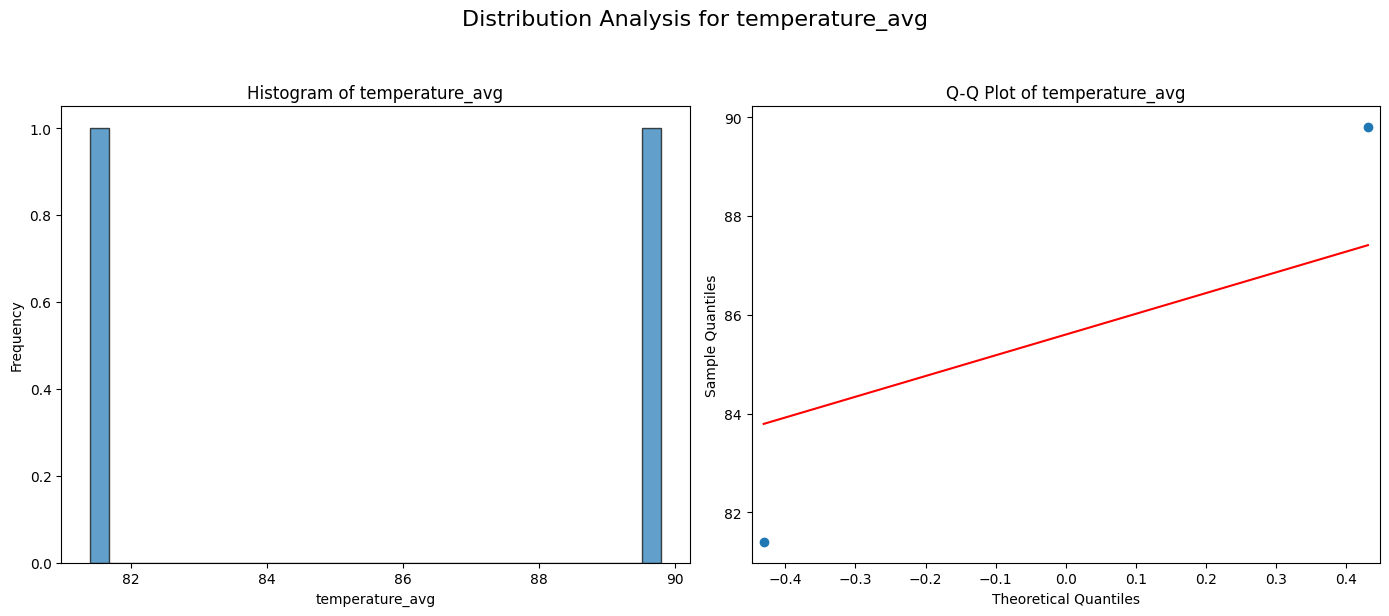

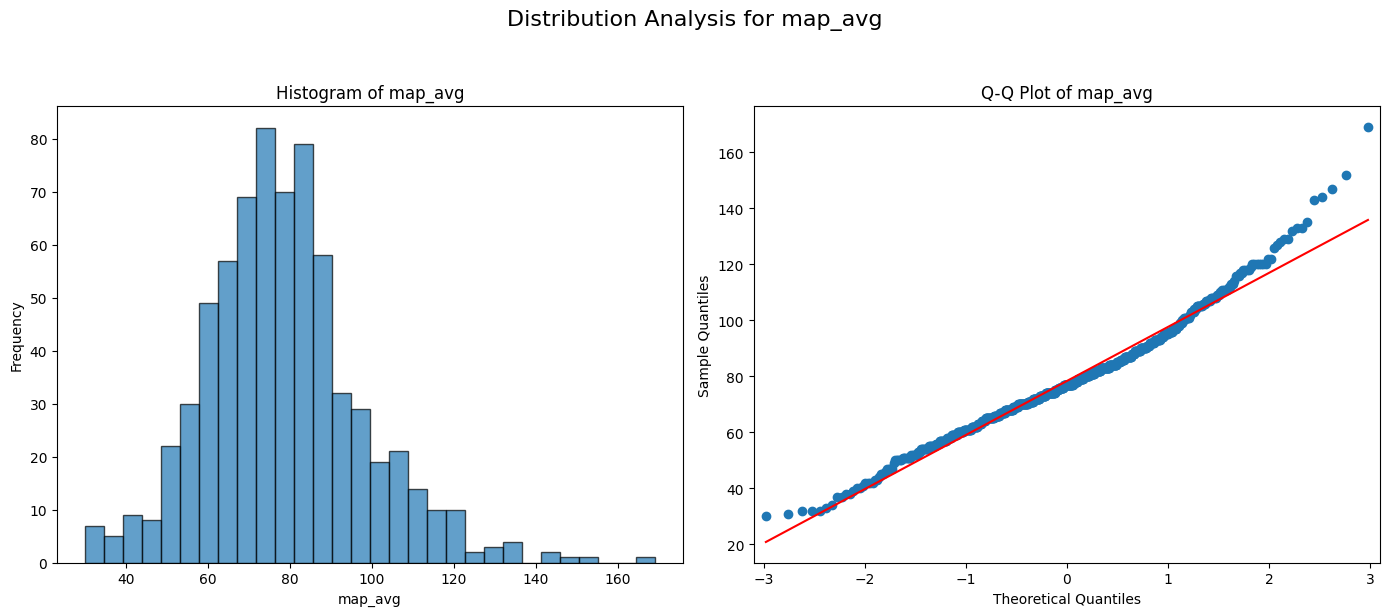

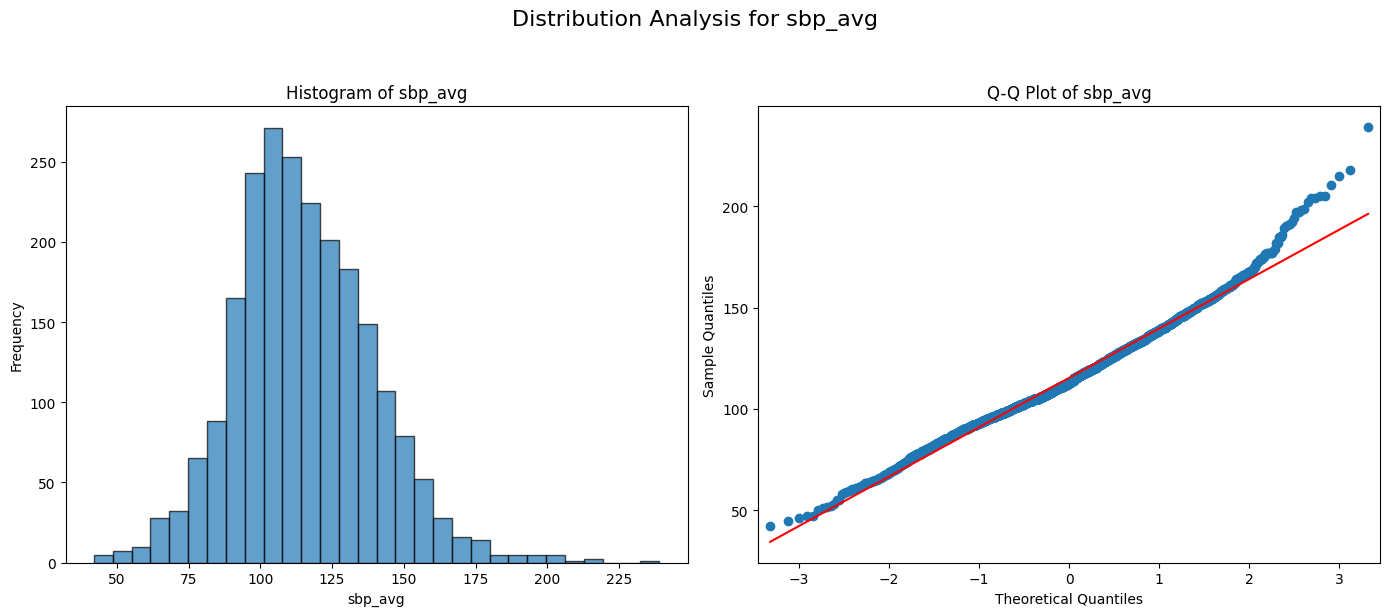

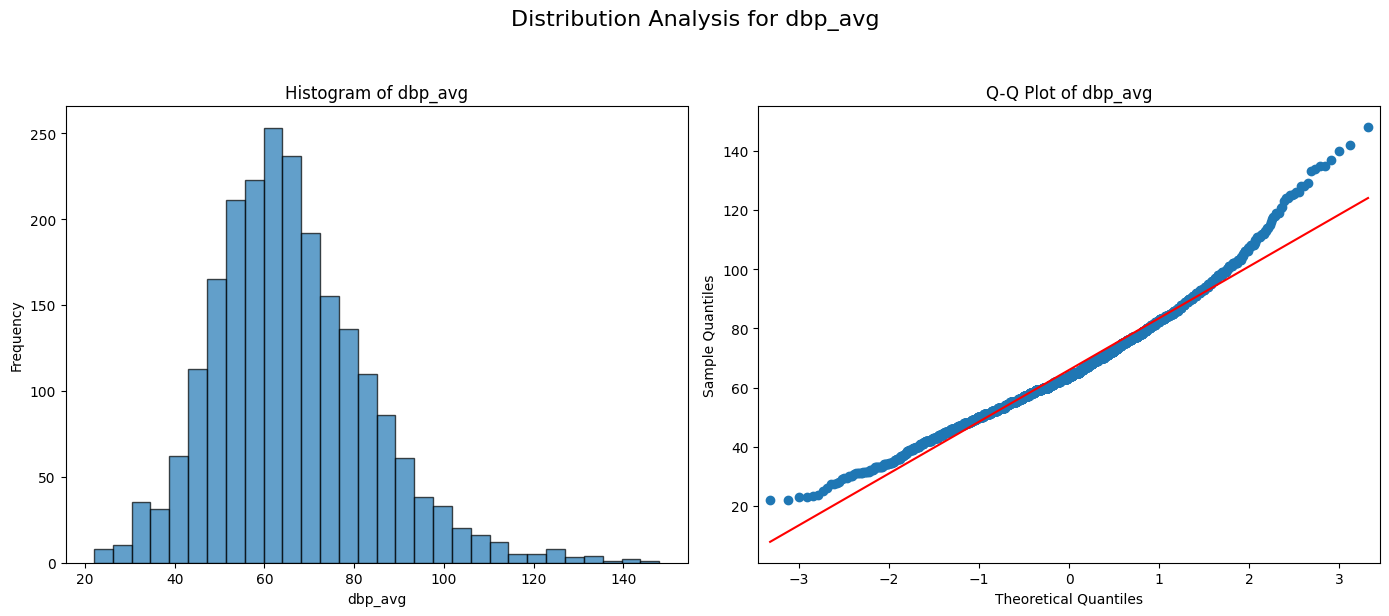

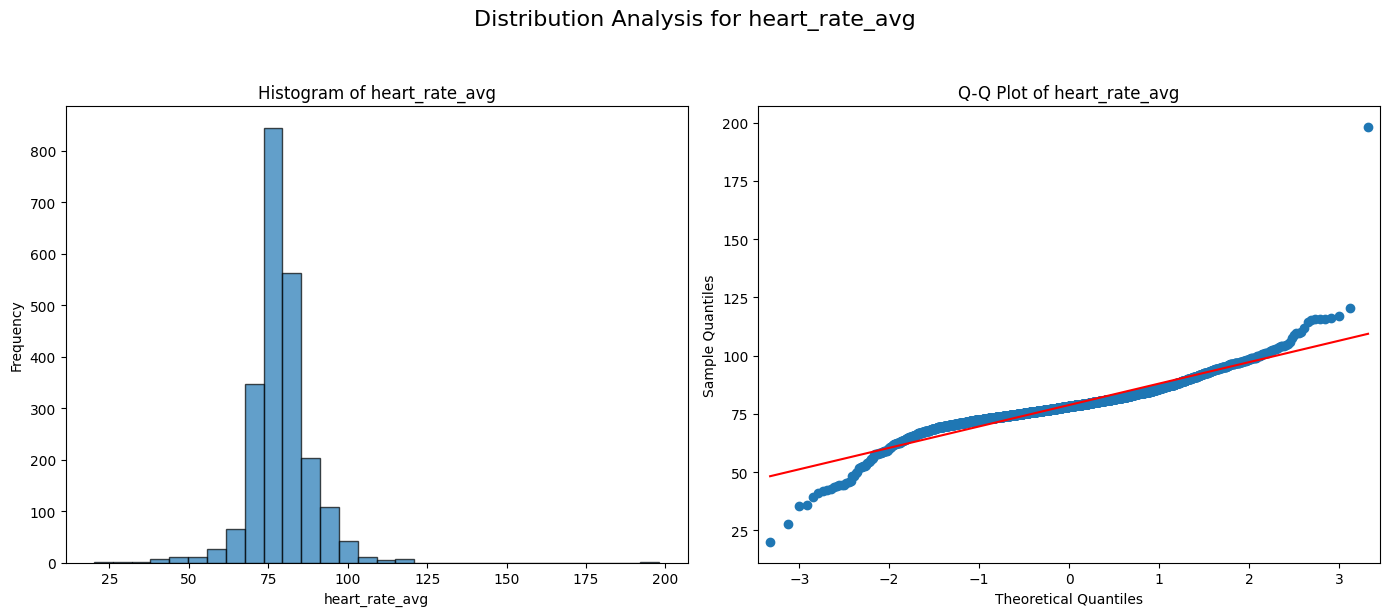

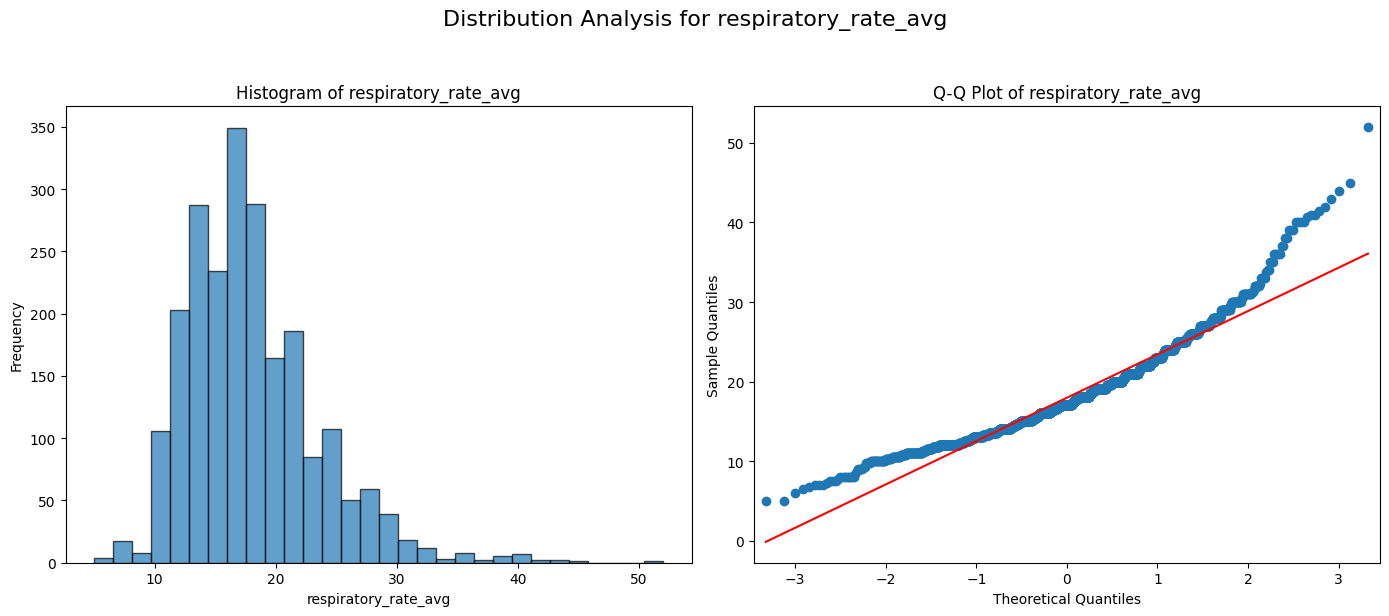

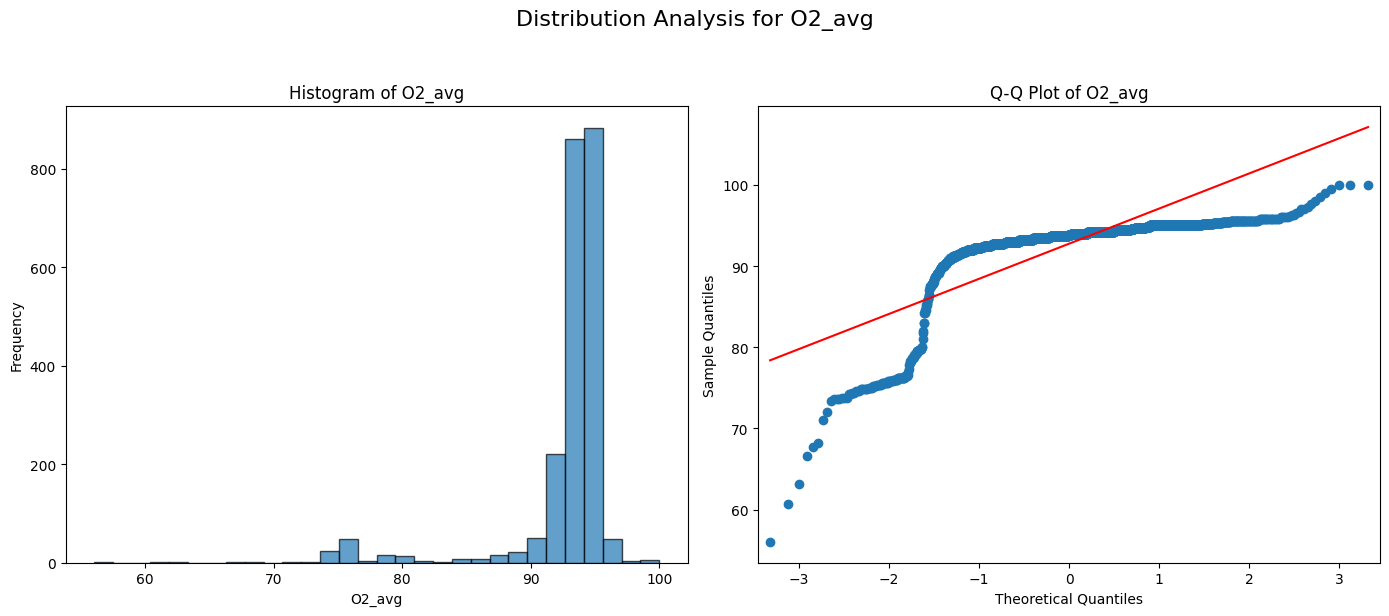

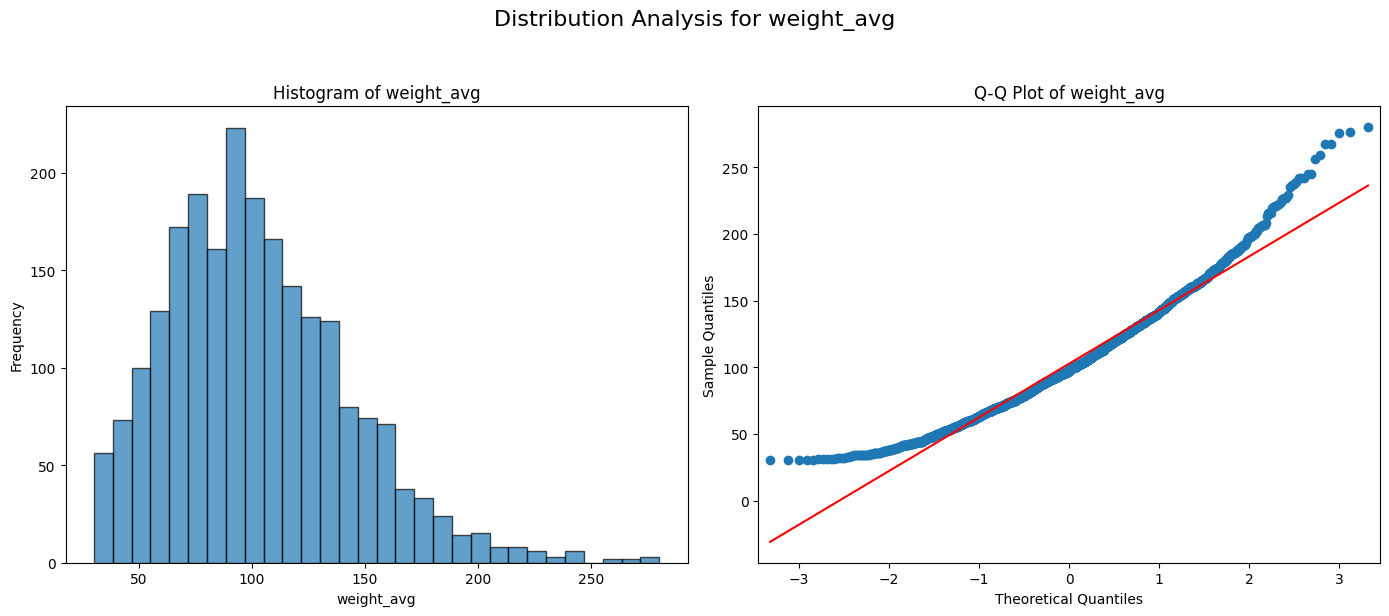

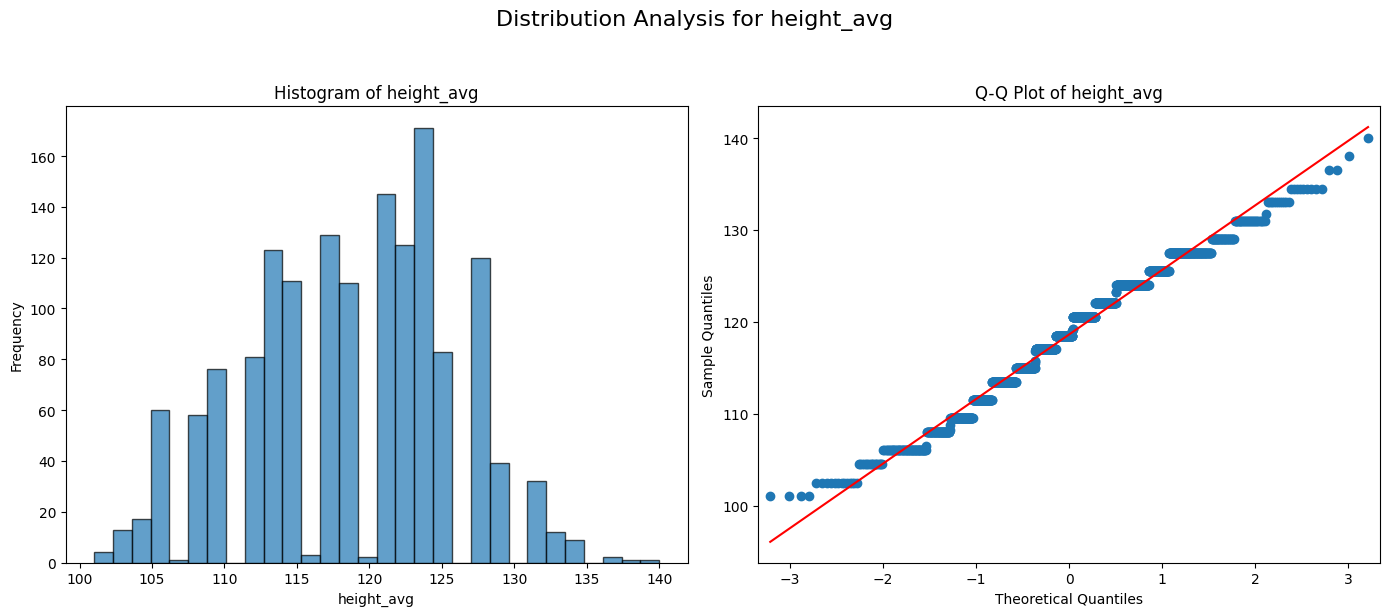

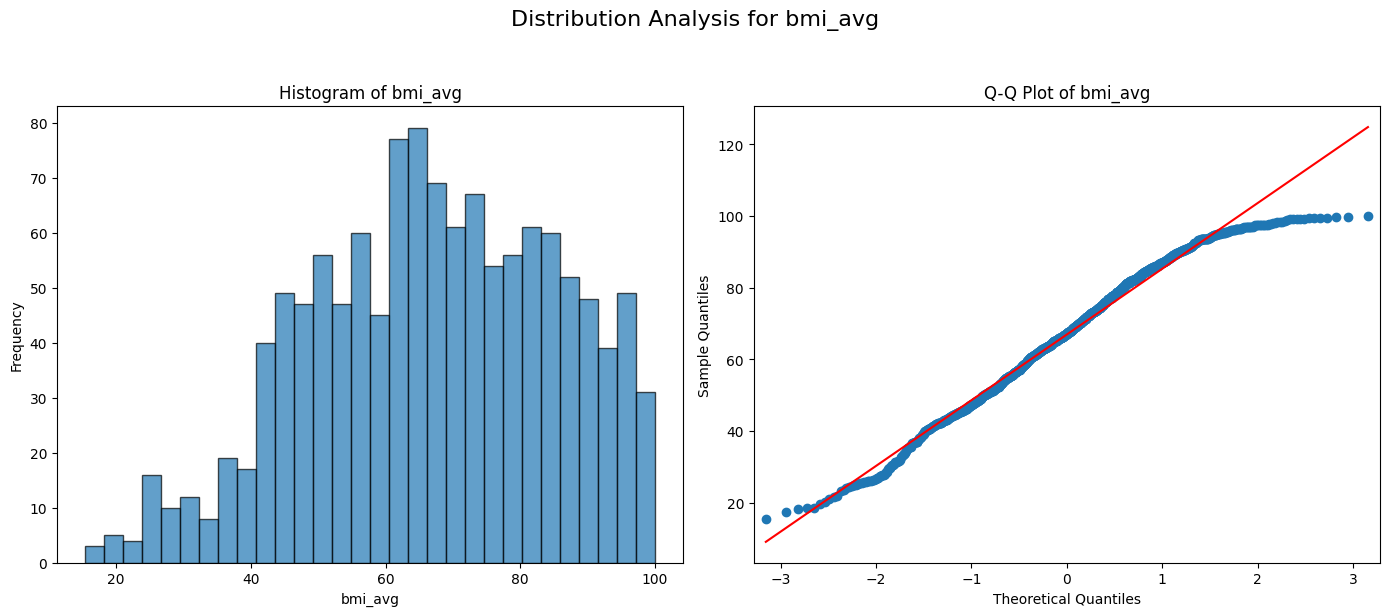

All plots generated.


In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm

# `columns_to_plot` is already defined in the previous cell and contains the non-comorbidity, non-mortality_flag numeric columns.
# We will iterate through these.

print("Generating Q-Q plots and Histograms...")

for column in columns_to_plot:
    # Drop NaN values for the current column to ensure plots work correctly
    data = df_avg[column].dropna()

    if not data.empty:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6)) # 1 row, 2 columns for side-by-side plots

        # Histogram
        axes[0].hist(data, bins=30, edgecolor='black', alpha=0.7)
        axes[0].set_title(f'Histogram of {column}')
        axes[0].set_xlabel(column)
        axes[0].set_ylabel('Frequency')

        # Q-Q Normal Plot
        sm.qqplot(data, line='s', ax=axes[1]) # 's' for standardized line (mean 0, std dev 1)
        axes[1].set_title(f'Q-Q Plot of {column}')
        axes[1].set_xlabel('Theoretical Quantiles')
        axes[1].set_ylabel('Sample Quantiles')

        plt.suptitle(f'Distribution Analysis for {column}', fontsize=16, y=1.02) # Overall title
        plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to make space for suptitle
        plt.show()
    else:
        print(f"Skipping {column} as it contains no valid data after dropping NaNs.")

print("All plots generated.")

# Statistical Analysis for Labs + Vitals (Mann-Whitney U-test)

In [ ]:
from scipy.stats import mannwhitneyu

print("Mann-Whitney U-Test Results for Numerical Variables vs. Mortality Flag:")

# `columns_to_plot` is already defined and contains the numerical columns excluding comorbidities and 'mortality_flag'

for col in columns_to_plot:
    # Separate data into alive and dead groups for the current column
    group_alive = df_avg[df_avg['mortality_flag'] == 0][col].dropna()
    group_dead = df_avg[df_avg['mortality_flag'] == 1][col].dropna()

    # Only perform the test if both groups have data
    if not group_alive.empty and not group_dead.empty:
        # Perform the Mann-Whitney U-test
        u_statistic, p_value = mannwhitneyu(group_alive, group_dead, alternative='two-sided')

        print(f"\n--- {col} ---")
        print(f"Mann-Whitney U Statistic: {u_statistic:.4f}")
        print(f"P-value: {p_value:.4f}")
        if p_value < 0.05:
            print("Conclusion: There is a statistically significant difference in the distribution of this variable between alive and dead patients (p < 0.05).")
        else:
            print("Conclusion: There is no statistically significant difference in the distribution of this variable between alive and dead patients (p >= 0.05).")
    else:
        print(f"\n--- {col} ---")
        print("Skipping test: Insufficient data in one or both mortality groups after dropping NaNs.")

Mann-Whitney U-Test Results for Numerical Variables vs. Mortality Flag:

--- rbc_avg ---
Mann-Whitney U Statistic: 2246638.5000
P-value: 0.0229
Conclusion: There is a statistically significant difference in the distribution of this variable between alive and dead patients (p < 0.05).

--- wbc_avg ---
Mann-Whitney U Statistic: 1960513.0000
P-value: 0.0000
Conclusion: There is a statistically significant difference in the distribution of this variable between alive and dead patients (p < 0.05).

--- hgb_avg ---
Mann-Whitney U Statistic: 3251603.0000
P-value: 0.7862
Conclusion: There is no statistically significant difference in the distribution of this variable between alive and dead patients (p >= 0.05).

--- plt_avg ---
Mann-Whitney U Statistic: 2538422.5000
P-value: 0.0000
Conclusion: There is a statistically significant difference in the distribution of this variable between alive and dead patients (p < 0.05).

--- rdw_avg ---
Mann-Whitney U Statistic: 2763965.0000
P-value: 0.0000
Co

## For Comorbid Diseases, 2*2 Contingency tables

In [ ]:
for col in comorbidity_cols:
    print(f"\nContingency Table for {col} vs. Mortality Flag:")
    contingency_table = pd.crosstab(df_avg[col], df_avg['mortality_flag'])
    contingency_table.index = [f'No {col}', f'Has {col}']
    contingency_table.columns = ['Alive', 'Dead']
    display(contingency_table)


Contingency Table for myocardial_infarction vs. Mortality Flag:


,Alive,Dead
No myocardial_infarction,4299,1255
Has myocardial_infarction,395,278



Contingency Table for congestive_heart_failure vs. Mortality Flag:


,Alive,Dead
No congestive_heart_failure,3830,1115
Has congestive_heart_failure,864,418



Contingency Table for peripheral_vascular_disease vs. Mortality Flag:


...

,Alive,Dead
No malignant_cancer,3867,1064
Has malignant_cancer,827,469



Contingency Table for severe_liver_disease vs. Mortality Flag:


,Alive,Dead
No severe_liver_disease,1204,781
Has severe_liver_disease,3490,752



Contingency Table for aids vs. Mortality Flag:


,Alive,Dead
No aids,4631,1509
Has aids,63,24


# Statistical Analysis for Comorbidities vs. Mortality Flag (Chi-square test)

In [ ]:
from scipy.stats import chi2_contingency

print("Chi-square Test Results for Comorbidities vs. Mortality Flag:")
for col in comorbidity_cols:
    # Create a 2x2 contingency table
    contingency_table = pd.crosstab(df_avg[col], df_avg['mortality_flag'])

    # Perform the Chi-square test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    print(f"\n--- {col} ---")
    print("Contingency Table:")
    contingency_table.index = [f'No {col}', f'Has {col}']
    contingency_table.columns = ['Alive', 'Dead']
    display(contingency_table)
    print(f"Chi-square Statistic: {chi2:.4f}")
    print(f"P-value: {p_value:.4f}")
    print(f"Degrees of Freedom: {dof}")
    if p_value < 0.05:
        print("Conclusion: There is a statistically significant association between this comorbidity and mortality (p < 0.05).")
    else:
        print("Conclusion: There is no statistically significant association between this comorbidity and mortality (p >= 0.05).")

Chi-square Test Results for Comorbidities vs. Mortality Flag:

--- myocardial_infarction ---
Contingency Table:


,Alive,Dead
No myocardial_infarction,4299,1255
Has myocardial_infarction,395,278


Chi-square Statistic: 112.2393
P-value: 0.0000
Degrees of Freedom: 1
Conclusion: There is a statistically significant association between this comorbidity and mortality (p < 0.05).

--- congestive_heart_failure ---
Contingency Table:


,Alive,Dead
No congestive_heart_failure,3830,1115
Has congestive_heart_failure,864,418


Chi-square Statistic: 54.9486
P-value: 0.0000
Degrees of Freedom: 1
Conclusion: There is a statistically significant association between this comorbidity and mortality (p < 0.05).

--- peripheral_vascular_disease ---
Contingency Table:


...

Chi-square Statistic: 117.2634
P-value: 0.0000
Degrees of Freedom: 1
Conclusion: There is a statistically significant association between this comorbidity and mortality (p < 0.05).

--- severe_liver_disease ---
Contingency Table:


,Alive,Dead
No severe_liver_disease,1204,781
Has severe_liver_disease,3490,752


Chi-square Statistic: 339.3539
P-value: 0.0000
Degrees of Freedom: 1
Conclusion: There is a statistically significant association between this comorbidity and mortality (p < 0.05).

--- aids ---
Contingency Table:


,Alive,Dead
No aids,4631,1509
Has aids,63,24


Chi-square Statistic: 0.2722
P-value: 0.6018
Degrees of Freedom: 1
Conclusion: There is no statistically significant association between this comorbidity and mortality (p >= 0.05).
